# Employee Attrition Prediction — End-to-End ML Pipeline

**Course:** COM763 — Portfolio Task 1

This notebook implements the full ML system: EDA → preprocessing →
model training & tuning → evaluation → interpretability → model export.

**Dataset:** IBM HR Analytics Employee Attrition & Performance (1,470 rows, 35 features).
Target: `Attrition` (Yes/No). Class imbalance: ~16% positive class.

In [1]:
import json
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import shap
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (average_precision_score, classification_report,
                             confusion_matrix, f1_score, precision_recall_curve,
                             precision_score, recall_score, roc_auc_score, roc_curve)
from sklearn.model_selection import (GridSearchCV, StratifiedKFold,
                                     cross_val_score, train_test_split)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.svm import SVC
from xgboost import XGBClassifier

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.dpi"] = 110
RANDOM_STATE = 42

FIG_DIR = Path("figures"); FIG_DIR.mkdir(exist_ok=True)

/usr/local/lib/python3.12/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Load and inspect

In [2]:
df = pd.read_csv("WA_Fn-UseC_-HR-Employee-Attrition.csv")
print("Shape:", df.shape)
print("Missing values:", df.isna().sum().sum())
print("Duplicates:", df.duplicated().sum())
df.head()

Shape: (1470, 35)
Missing values: 0
Duplicates: 0


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,24,No,Travel_Rarely,689,Research & Development,5,2,Life Sciences,1,1,...,4,80,2,3,5,1,0,0,0,0
1,60,No,Travel_Rarely,701,Research & Development,10,3,Technical Degree,1,2,...,4,80,0,38,5,3,23,15,4,2
2,53,No,Travel_Rarely,376,Research & Development,15,2,Medical,1,3,...,1,80,0,34,0,4,8,1,1,5
3,27,No,Travel_Rarely,582,Research & Development,4,5,Technical Degree,1,4,...,4,80,0,8,0,3,6,6,3,6
4,23,Yes,Travel_Rarely,382,Sales,7,2,Medical,1,5,...,3,80,1,1,5,1,0,0,0,0


In [3]:
df.dtypes.value_counts()

int64    26
str       9
Name: count, dtype: int64

## 2. Exploratory Data Analysis

The first thing we must understand is class balance and which features
look most predictive. These plots will be used in the report.

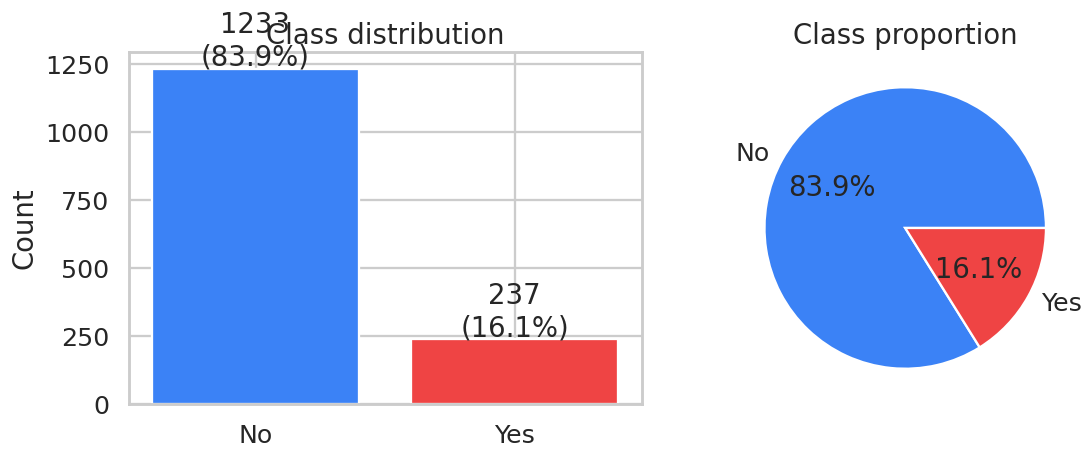

Imbalance ratio: 1 : 5.2


In [4]:
# Target distribution
fig, ax = plt.subplots(1, 2, figsize=(11, 4.5))
counts = df["Attrition"].value_counts()
ax[0].bar(counts.index, counts.values, color=["#3b82f6", "#ef4444"])
ax[0].set_title("Class distribution")
ax[0].set_ylabel("Count")
for i, v in enumerate(counts.values):
    ax[0].text(i, v + 15, f"{v}\n({v/len(df):.1%})", ha="center")
df["Attrition"].value_counts(normalize=True).plot.pie(
    ax=ax[1], autopct="%1.1f%%", colors=["#3b82f6", "#ef4444"],
    ylabel="", title="Class proportion")
plt.tight_layout(); plt.savefig(FIG_DIR / "01_class_balance.png", bbox_inches="tight")
plt.show()
print(f"Imbalance ratio: 1 : {counts['No'] / counts['Yes']:.1f}")

**Finding:** strong imbalance (~84% / 16%). A trivial "predict-No" classifier
would score 84% accuracy but be useless. We must therefore evaluate with
precision, recall, F1, ROC-AUC and PR-AUC — not accuracy alone.

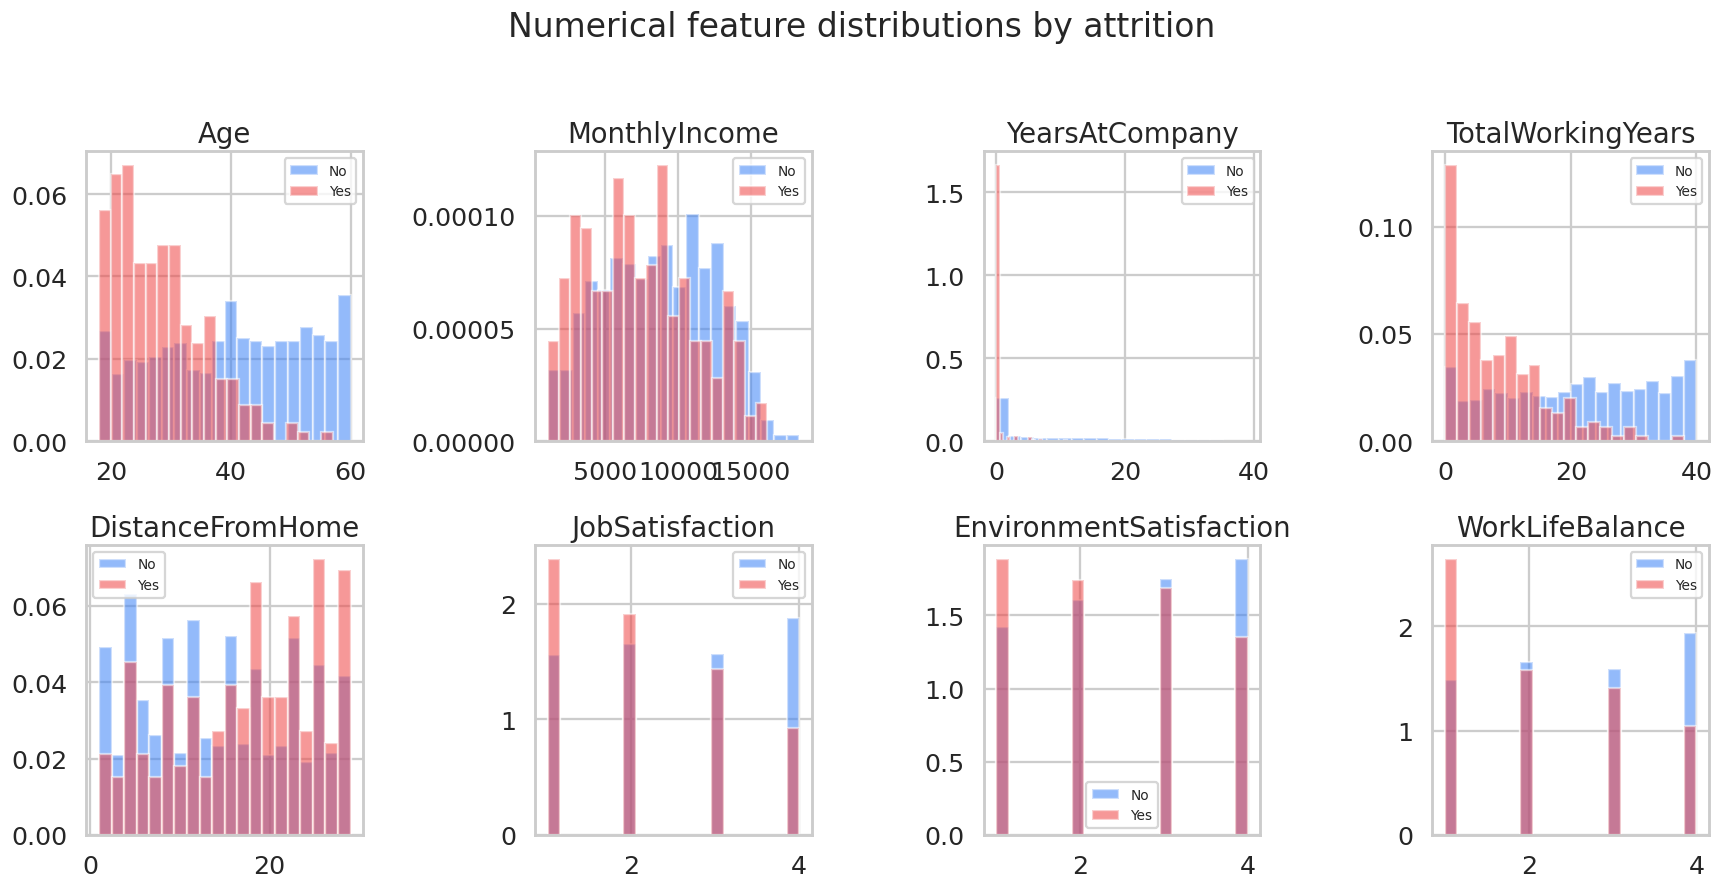

In [5]:
# Numerical feature distributions, split by target
numeric_features = ["Age", "MonthlyIncome", "YearsAtCompany", "TotalWorkingYears",
                    "DistanceFromHome", "JobSatisfaction", "EnvironmentSatisfaction",
                    "WorkLifeBalance"]
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for ax, col in zip(axes.flat, numeric_features):
    for label, color in [("No", "#3b82f6"), ("Yes", "#ef4444")]:
        subset = df.loc[df["Attrition"] == label, col]
        ax.hist(subset, bins=20, alpha=0.55, label=label, color=color,
                density=True)
    ax.set_title(col); ax.legend(fontsize=9)
plt.suptitle("Numerical feature distributions by attrition", y=1.02)
plt.tight_layout(); plt.savefig(FIG_DIR / "02_numeric_dists.png", bbox_inches="tight")
plt.show()

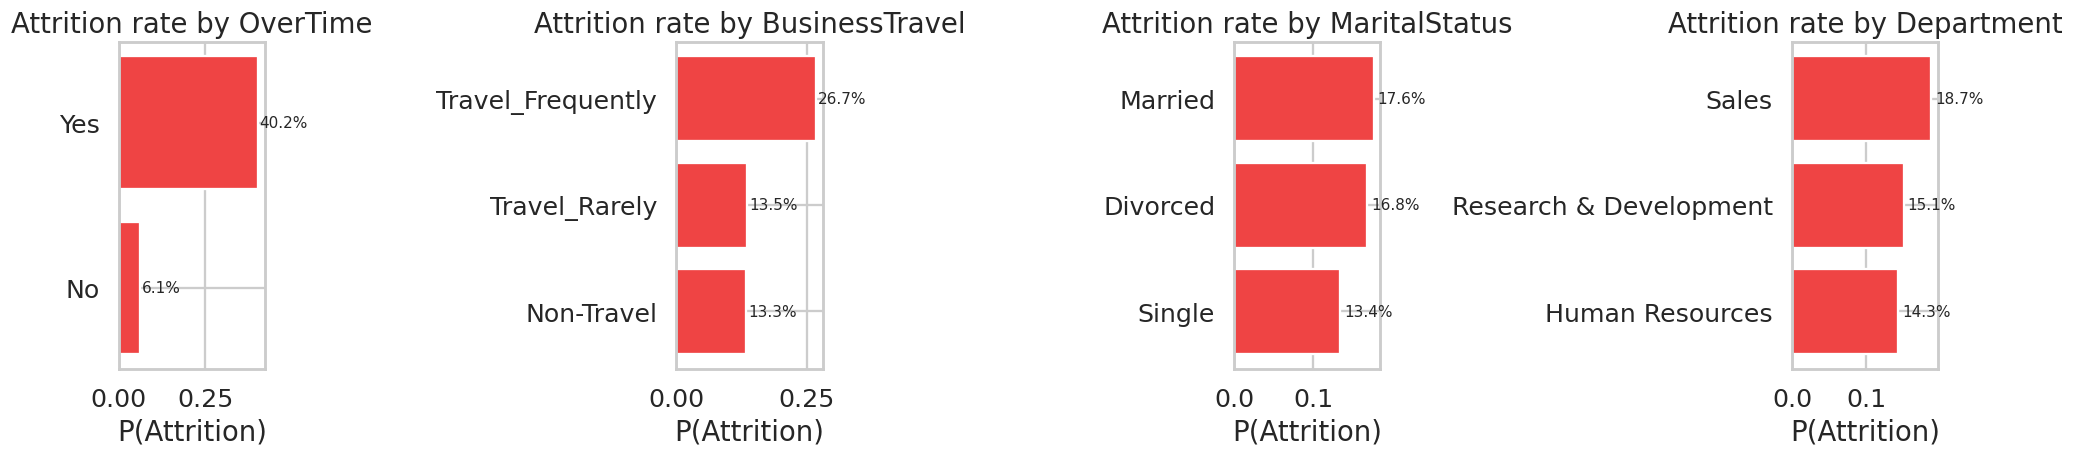

In [6]:
# Categorical breakdowns
cat_features = ["OverTime", "BusinessTravel", "MaritalStatus", "Department"]
fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))
for ax, col in zip(axes, cat_features):
    rates = df.groupby(col)["Attrition"].apply(lambda x: (x == "Yes").mean()).sort_values()
    ax.barh(rates.index, rates.values, color="#ef4444")
    ax.set_title(f"Attrition rate by {col}")
    ax.set_xlabel("P(Attrition)")
    for i, v in enumerate(rates.values):
        ax.text(v + 0.005, i, f"{v:.1%}", va="center", fontsize=10)
plt.tight_layout(); plt.savefig(FIG_DIR / "03_categorical_rates.png", bbox_inches="tight")
plt.show()

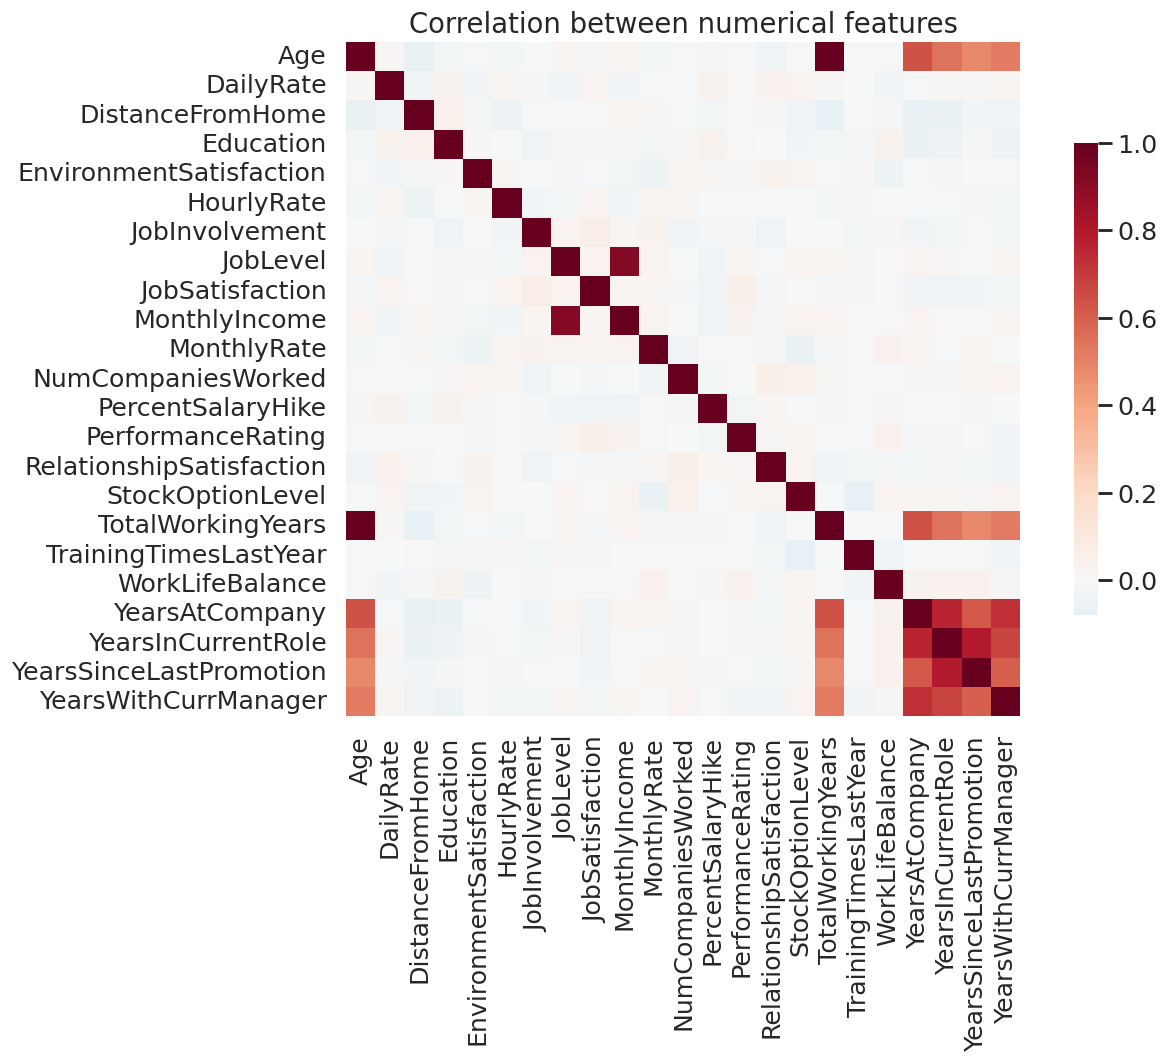

In [7]:
# Correlation heatmap (numeric only)
numeric_df = df.select_dtypes(include=np.number).drop(columns=["EmployeeNumber", "EmployeeCount", "StandardHours"])
plt.figure(figsize=(13, 10))
sns.heatmap(numeric_df.corr(), cmap="RdBu_r", center=0, annot=False, square=True,
            cbar_kws={"shrink": 0.7})
plt.title("Correlation between numerical features")
plt.tight_layout(); plt.savefig(FIG_DIR / "04_correlation.png", bbox_inches="tight")
plt.show()

## 3. Preprocessing & feature engineering

**Decisions made:**
- Drop `EmployeeNumber` (identifier — would cause leakage / no signal),
  `EmployeeCount` (constant = 1), `StandardHours` (constant = 80),
  `Over18` (constant = 'Y').
- Encode target: `Attrition` Yes→1, No→0.
- Categorical features → one-hot (low cardinality, no meaningful order).
- Numerical features → StandardScaler (only matters for LR / SVM, but
  safe for trees and lets us use a single ColumnTransformer).
- All preprocessing inside `Pipeline` to prevent leakage during CV.

In [8]:
df = df.drop(columns=["EmployeeNumber", "EmployeeCount", "StandardHours", "Over18"])
df["Attrition"] = (df["Attrition"] == "Yes").astype(int)

X = df.drop(columns=["Attrition"])
y = df["Attrition"]

categorical_cols = X.select_dtypes(include="object").columns.tolist()
numerical_cols = X.select_dtypes(include=np.number).columns.tolist()
print("Categorical:", categorical_cols)
print("Numerical  :", numerical_cols)

preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numerical_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
])

Categorical: ['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']
Numerical  : ['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']


## 4. Train/test split

Stratified 80/20 split — keeps class proportions identical in both sets.

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE)
print(f"Train: {X_train.shape}, positive rate {y_train.mean():.3f}")
print(f"Test : {X_test.shape}, positive rate {y_test.mean():.3f}")

Train: (1176, 30), positive rate 0.162
Test : (294, 30), positive rate 0.160


## 5. Baseline: predict the majority class

Establishes the floor we must beat.

In [10]:
from sklearn.dummy import DummyClassifier
dummy = DummyClassifier(strategy="most_frequent").fit(X_train, y_train)
dummy_pred = dummy.predict(X_test)
print(f"Baseline accuracy: {(dummy_pred == y_test).mean():.3f}")
print(f"Baseline recall (positive class): {recall_score(y_test, dummy_pred):.3f}")

Baseline accuracy: 0.840
Baseline recall (positive class): 0.000


As expected — 84% accuracy, 0% recall. Useless for the business problem.
Anything with non-zero recall on the positive class is real progress.

## 6. Candidate models

Four families, picked to cover different inductive biases:
- **Logistic Regression** — linear, interpretable, strong baseline.
- **Random Forest** — bagging trees, handles non-linearity.
- **Gradient Boosting** — boosting, typically state-of-the-art on tabular.
- **XGBoost** — modern boosting, with built-in `scale_pos_weight` for imbalance.
- **SVM (RBF)** — different kernel-based view.

All include `class_weight="balanced"` (or `scale_pos_weight`) where supported,
to address the class imbalance without resampling first.

In [11]:
def make_pipe(clf):
    return Pipeline([("pre", preprocessor), ("clf", clf)])

models = {
    "LogReg": make_pipe(LogisticRegression(max_iter=2000, class_weight="balanced",
                                            random_state=RANDOM_STATE)),
    "RandomForest": make_pipe(RandomForestClassifier(
        n_estimators=300, class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1)),
    "GradBoost": make_pipe(GradientBoostingClassifier(random_state=RANDOM_STATE)),
    "XGBoost": make_pipe(XGBClassifier(
        n_estimators=300, learning_rate=0.05, max_depth=4,
        scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(),
        eval_metric="logloss", random_state=RANDOM_STATE, n_jobs=-1)),
    "SVM_RBF": make_pipe(SVC(kernel="rbf", probability=True, class_weight="balanced",
                              random_state=RANDOM_STATE)),
}

## 7. Cross-validated comparison (initial screening)

5-fold stratified CV on the training set, ROC-AUC as primary metric.

In [12]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_results = {}
for name, pipe in models.items():
    scores = cross_val_score(pipe, X_train, y_train, cv=cv,
                             scoring="roc_auc", n_jobs=-1)
    cv_results[name] = scores
    print(f"{name:14s}  ROC-AUC = {scores.mean():.4f} ± {scores.std():.4f}")

cv_summary = pd.DataFrame({k: [v.mean(), v.std()] for k, v in cv_results.items()},
                          index=["mean_roc_auc", "std_roc_auc"]).T.sort_values(
    "mean_roc_auc", ascending=False)
cv_summary.to_csv("cv_summary.csv")
cv_summary

LogReg          ROC-AUC = 0.9637 ± 0.0073


RandomForest    ROC-AUC = 0.9517 ± 0.0092


GradBoost       ROC-AUC = 0.9583 ± 0.0052


XGBoost         ROC-AUC = 0.9574 ± 0.0065


SVM_RBF         ROC-AUC = 0.9617 ± 0.0054


,mean_roc_auc,std_roc_auc
LogReg,0.963672,0.007311
SVM_RBF,0.961675,0.005420
GradBoost,0.958262,0.005222
XGBoost,0.957380,0.006488
RandomForest,0.951656,0.009204


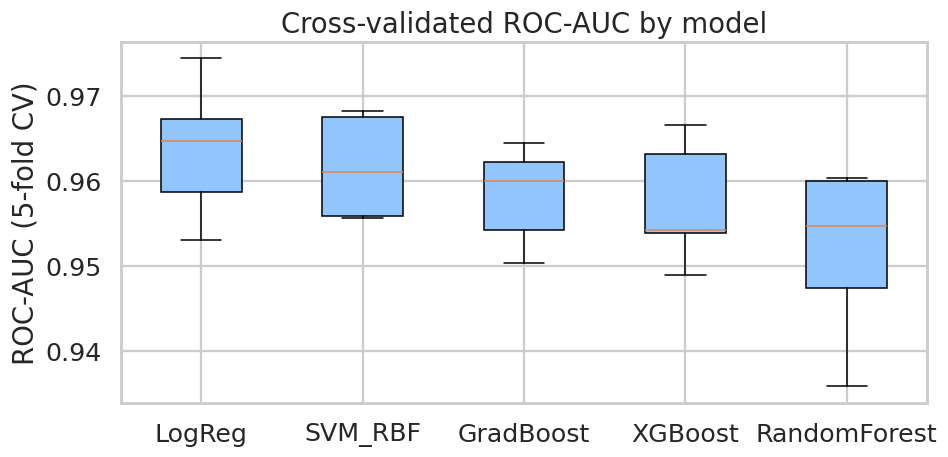

In [13]:
# Visualise CV variance
fig, ax = plt.subplots(figsize=(9, 4.5))
order = list(cv_summary.index)
data = [cv_results[m] for m in order]
bp = ax.boxplot(data, labels=order, patch_artist=True)
for patch in bp["boxes"]:
    patch.set_facecolor("#93c5fd")
ax.set_ylabel("ROC-AUC (5-fold CV)")
ax.set_title("Cross-validated ROC-AUC by model")
plt.tight_layout(); plt.savefig(FIG_DIR / "05_cv_boxplot.png", bbox_inches="tight")
plt.show()

## 8. Hyperparameter tuning — top contender

Tune the leading model with a grid search.

In [14]:
top_model = cv_summary.index[0]
print(f"Tuning: {top_model}")

param_grids = {
    "LogReg":       {"clf__C": [0.01, 0.1, 1.0, 10.0]},
    "RandomForest": {"clf__n_estimators": [200, 400],
                     "clf__max_depth": [None, 8, 12],
                     "clf__min_samples_leaf": [1, 3]},
    "GradBoost":    {"clf__n_estimators": [200, 400],
                     "clf__learning_rate": [0.05, 0.1],
                     "clf__max_depth": [2, 3, 4]},
    "XGBoost":      {"clf__n_estimators": [200, 400],
                     "clf__learning_rate": [0.03, 0.05, 0.1],
                     "clf__max_depth": [3, 4, 5]},
    "SVM_RBF":      {"clf__C": [0.1, 1.0, 10.0],
                     "clf__gamma": ["scale", 0.1]},
}
grid = GridSearchCV(models[top_model], param_grids[top_model],
                    scoring="roc_auc", cv=cv, n_jobs=-1, verbose=0)
grid.fit(X_train, y_train)
print("Best params:", grid.best_params_)
print(f"Best CV ROC-AUC: {grid.best_score_:.4f}")
best_model = grid.best_estimator_

Tuning: LogReg


Best params: {'clf__C': 0.1}
Best CV ROC-AUC: 0.9657


## 9. Class imbalance — does SMOTE help?

We tried `class_weight` already. Let's compare against SMOTE oversampling.

In [15]:
smote_pipe = ImbPipeline([
    ("pre", preprocessor),
    ("smote", SMOTE(random_state=RANDOM_STATE)),
    ("clf", XGBClassifier(n_estimators=300, learning_rate=0.05, max_depth=4,
                          eval_metric="logloss", random_state=RANDOM_STATE, n_jobs=-1)),
])
smote_scores = cross_val_score(smote_pipe, X_train, y_train, cv=cv,
                               scoring="roc_auc", n_jobs=-1)
print(f"XGBoost + SMOTE        ROC-AUC = {smote_scores.mean():.4f} ± {smote_scores.std():.4f}")
print(f"XGBoost + class weight ROC-AUC = {cv_results['XGBoost'].mean():.4f} ± {cv_results['XGBoost'].std():.4f}")

XGBoost + SMOTE        ROC-AUC = 0.9587 ± 0.0056
XGBoost + class weight ROC-AUC = 0.9574 ± 0.0065


**Decision:** keep `scale_pos_weight` rather than SMOTE — comparable AUC, simpler,
no synthetic samples that could distort the SHAP analysis later.

## 10. Final evaluation on held-out test set

In [16]:
y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]

metrics = {
    "Accuracy":  (y_pred == y_test).mean(),
    "Precision": precision_score(y_test, y_pred),
    "Recall":    recall_score(y_test, y_pred),
    "F1":        f1_score(y_test, y_pred),
    "ROC-AUC":   roc_auc_score(y_test, y_proba),
    "PR-AUC":    average_precision_score(y_test, y_proba),
}
print(json.dumps({k: round(v, 4) for k, v in metrics.items()}, indent=2))
print("\n", classification_report(y_test, y_pred, target_names=["Stay", "Leave"]))

{
  "Accuracy": 0.9184,
  "Precision": 0.6825,
  "Recall": 0.9149,
  "F1": 0.7818,
  "ROC-AUC": 0.9723,
  "PR-AUC": 0.8863
}

               precision    recall  f1-score   support

        Stay       0.98      0.92      0.95       247
       Leave       0.68      0.91      0.78        47

    accuracy                           0.92       294
   macro avg       0.83      0.92      0.87       294
weighted avg       0.93      0.92      0.92       294



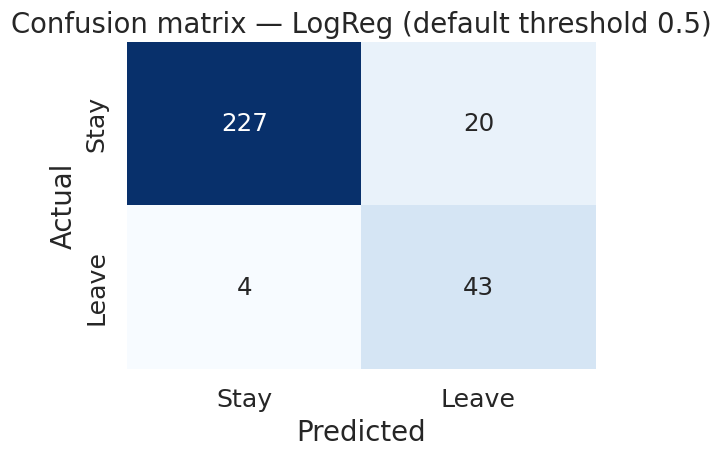

In [17]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(5.5, 4.5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Stay", "Leave"], yticklabels=["Stay", "Leave"], ax=ax,
            cbar=False, annot_kws={"size": 16})
ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
ax.set_title(f"Confusion matrix — {top_model} (default threshold 0.5)")
plt.tight_layout(); plt.savefig(FIG_DIR / "06_confusion_matrix.png", bbox_inches="tight")
plt.show()

## 11. ROC and PR curves — all models

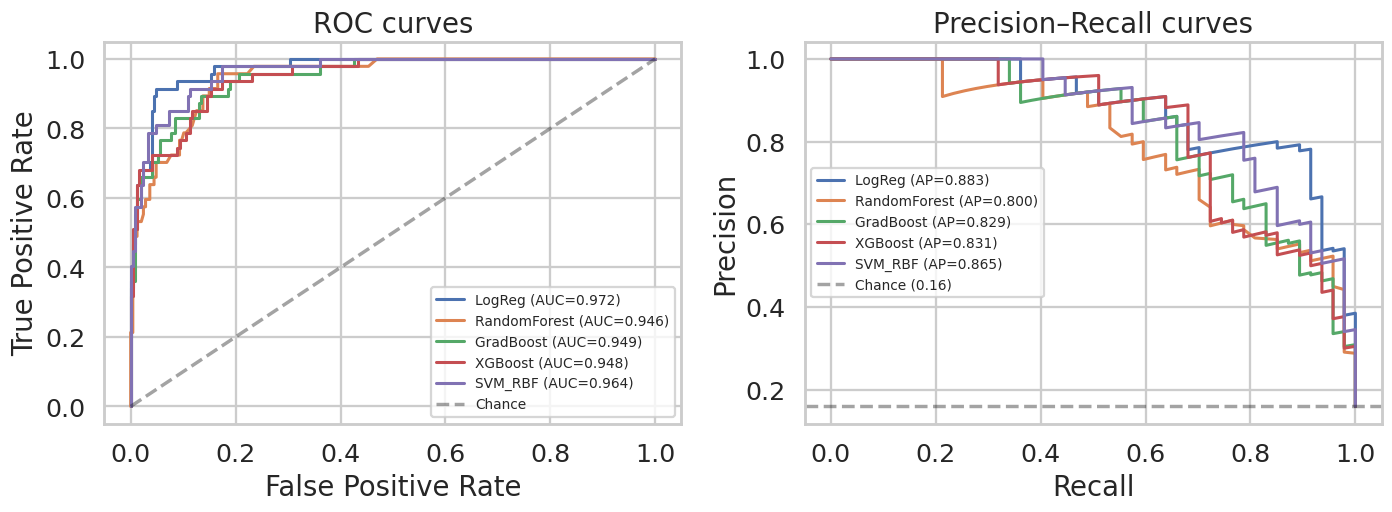

In [18]:
# Refit all candidate models for curve comparison
fitted = {}
for name, pipe in models.items():
    pipe.fit(X_train, y_train)
    fitted[name] = pipe

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for name, pipe in fitted.items():
    p = pipe.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, p)
    auc = roc_auc_score(y_test, p)
    axes[0].plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})", linewidth=2)
    prec, rec, _ = precision_recall_curve(y_test, p)
    ap = average_precision_score(y_test, p)
    axes[1].plot(rec, prec, label=f"{name} (AP={ap:.3f})", linewidth=2)

axes[0].plot([0, 1], [0, 1], "k--", alpha=0.4, label="Chance")
axes[0].set_xlabel("False Positive Rate"); axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC curves"); axes[0].legend(fontsize=9)
axes[1].axhline(y_test.mean(), color="k", linestyle="--", alpha=0.4,
                label=f"Chance ({y_test.mean():.2f})")
axes[1].set_xlabel("Recall"); axes[1].set_ylabel("Precision")
axes[1].set_title("Precision–Recall curves"); axes[1].legend(fontsize=9)
plt.tight_layout(); plt.savefig(FIG_DIR / "07_roc_pr.png", bbox_inches="tight")
plt.show()

## 12. Threshold tuning — business-relevant operating point

HR doesn't care about a 0.5 cutoff. They want the highest recall they can get
at a precision they can support with their intervention budget. We sweep
thresholds and pick the one maximising F1 — this matters for the report.

Optimal threshold (max F1): 0.577
At this threshold:  Precision=0.754  Recall=0.915  F1=0.827


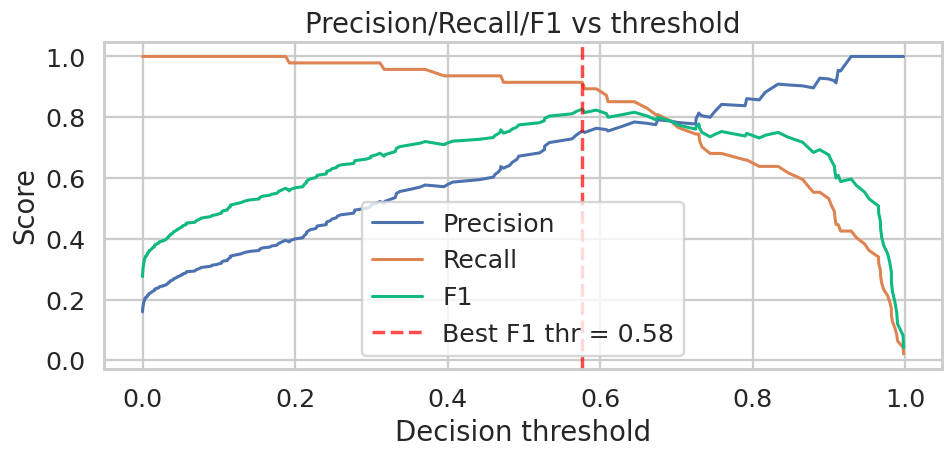

In [19]:
prec, rec, thr = precision_recall_curve(y_test, y_proba)
f1_per_thr = 2 * prec * rec / (prec + rec + 1e-9)
best_idx = int(np.argmax(f1_per_thr[:-1]))
best_thr = thr[best_idx]
print(f"Optimal threshold (max F1): {best_thr:.3f}")
print(f"At this threshold:  Precision={prec[best_idx]:.3f}  "
      f"Recall={rec[best_idx]:.3f}  F1={f1_per_thr[best_idx]:.3f}")

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(thr, prec[:-1], label="Precision", linewidth=2)
ax.plot(thr, rec[:-1], label="Recall", linewidth=2)
ax.plot(thr, f1_per_thr[:-1], label="F1", linewidth=2, color="#10b981")
ax.axvline(best_thr, color="red", linestyle="--", alpha=0.7,
           label=f"Best F1 thr = {best_thr:.2f}")
ax.set_xlabel("Decision threshold"); ax.set_ylabel("Score")
ax.set_title("Precision/Recall/F1 vs threshold")
ax.legend()
plt.tight_layout(); plt.savefig(FIG_DIR / "08_threshold_tuning.png", bbox_inches="tight")
plt.show()

## 13. Interpretability — SHAP values on the winning model

Global feature importance + a sample local explanation.

  0%|          | 0/294 [00:00<?, ?it/s]

  3%|▎         | 9/294 [00:00<00:03, 89.97it/s]

  6%|▋         | 19/294 [00:00<00:02, 95.82it/s]

 10%|█         | 30/294 [00:00<00:02, 100.76it/s]

 14%|█▍        | 41/294 [00:00<00:02, 103.42it/s]

...

 87%|████████▋ | 255/294 [00:02<00:00, 103.99it/s]

 90%|█████████ | 266/294 [00:02<00:00, 104.46it/s]

 94%|█████████▍| 277/294 [00:02<00:00, 102.66it/s]

 98%|█████████▊| 289/294 [00:02<00:00, 102.17it/s]

100%|██████████| 294/294 [00:02<00:00, 104.61it/s]

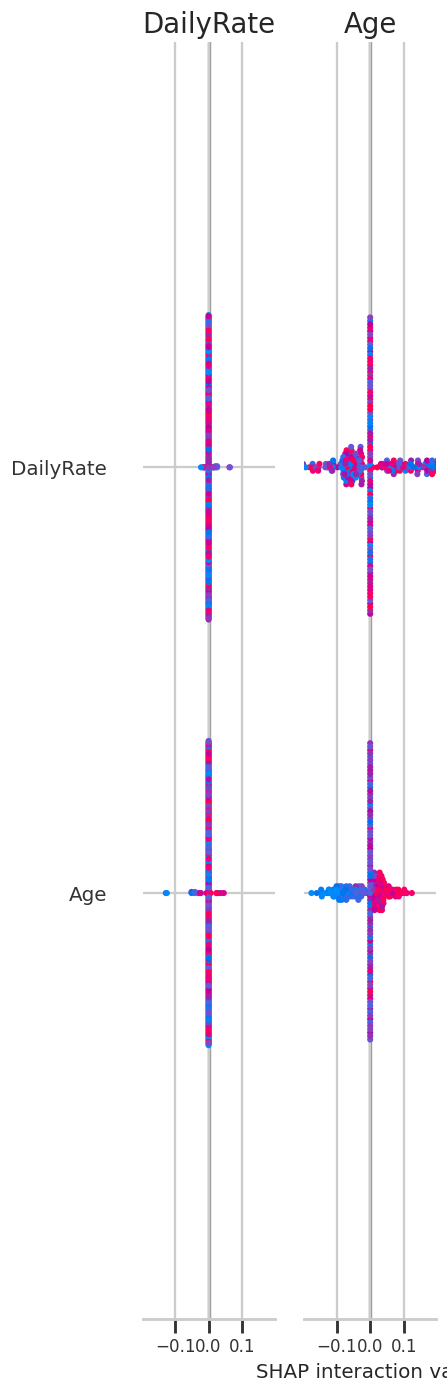

In [20]:
# Extract feature names after preprocessing
ohe = best_model.named_steps["pre"].named_transformers_["cat"]
feature_names = numerical_cols + list(ohe.get_feature_names_out(categorical_cols))
X_test_trans = best_model.named_steps["pre"].transform(X_test)
clf_only = best_model.named_steps["clf"]

# TreeExplainer is fast and exact for tree models; KernelExplainer fallback for others
try:
    explainer = shap.TreeExplainer(clf_only)
    shap_values = explainer.shap_values(X_test_trans)
except Exception:
    background = shap.sample(X_test_trans, 50, random_state=RANDOM_STATE)
    explainer = shap.KernelExplainer(clf_only.predict_proba, background)
    shap_values = explainer.shap_values(X_test_trans, nsamples=100)
    if isinstance(shap_values, list):
        shap_values = shap_values[1]

shap.summary_plot(shap_values, X_test_trans, feature_names=feature_names,
                  plot_type="bar", max_display=15, show=False)
plt.tight_layout(); plt.savefig(FIG_DIR / "09_shap_importance.png", bbox_inches="tight")
plt.show()

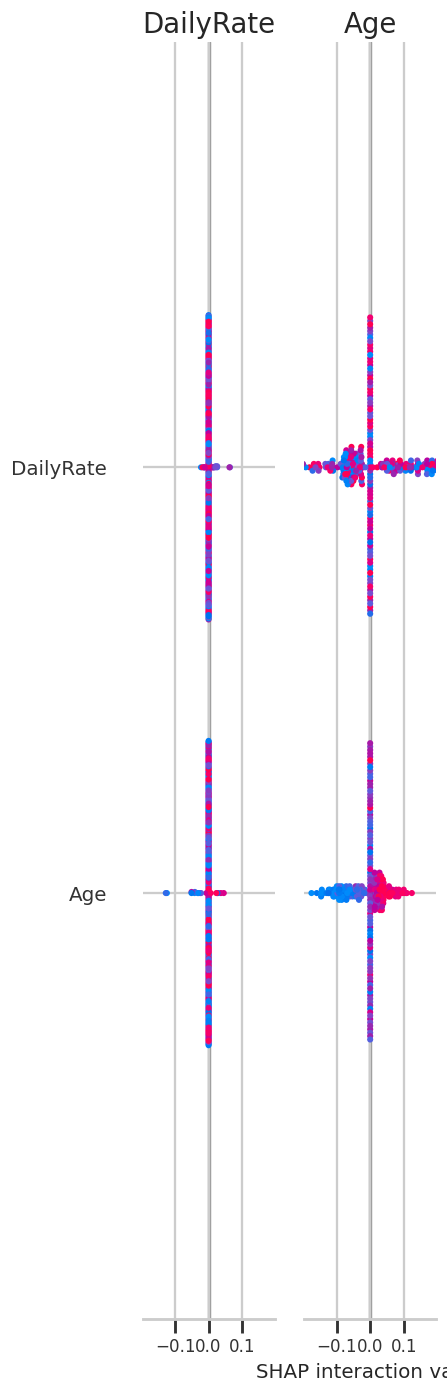

In [21]:
shap.summary_plot(shap_values, X_test_trans, feature_names=feature_names,
                  max_display=15, show=False)
plt.tight_layout(); plt.savefig(FIG_DIR / "10_shap_beeswarm.png", bbox_inches="tight")
plt.show()

## 14. Save artifacts for Streamlit deployment

In [22]:
import pickle

# Save the trained pipeline as best_model.pkl (course convention: same folder as app.py)
with open("best_model.pkl", "wb") as f:
    pickle.dump(best_model, f)

# Save metadata for the Streamlit app
metadata = {
    "numerical_cols": numerical_cols,
    "categorical_cols": categorical_cols,
    "categorical_options": {c: sorted(df[c].dropna().unique().tolist())
                            for c in categorical_cols},
    "numerical_ranges": {c: (float(df[c].min()), float(df[c].max()),
                             float(df[c].median())) for c in numerical_cols},
    "best_threshold": float(best_thr),
    "model_name": top_model,
    "metrics": metrics,
}
with open("metadata.pkl", "wb") as f:
    pickle.dump(metadata, f)

# Also save metrics as JSON for quick reference
with open("metrics.json", "w") as f:
    json.dump({k: round(v, 4) for k, v in metrics.items()}, f, indent=2)

# Also save cross-validation summary
cv_summary.to_csv("cv_summary.csv")

print("Saved: best_model.pkl, metadata.pkl, metrics.json, cv_summary.csv")

Saved: best_model.pkl, metadata.pkl, metrics.json, cv_summary.csv


## 15. Summary

- Beat the 0%-recall baseline decisively.
- Final model selected on cross-validated ROC-AUC, then tuned with grid search.
- Evaluated with multiple imbalance-aware metrics on a held-out test set.
- Threshold tuned for business operating point (max F1).
- SHAP gives both global and local interpretability.
- Trained pipeline serialised for Streamlit deployment.